In [29]:
#ANALISI RINNOVABILI 2021-2026 (TERNA)

In [3]:
!pip install openpyxl

In [2]:
import pandas as pd
import warnings

warnings.filterwarnings('ignore', category=UserWarning, module='openpyxl')

df_2021 = pd.read_excel("File anno per anno/Generazione_2021.xlsx")
df_2022 = pd.read_excel("File anno per anno/Generazione_2022.xlsx")
df_2023 = pd.read_excel("File anno per anno/Generazione_2023.xlsx")
df_2024 = pd.read_excel("File anno per anno/Generazione_2024.xlsx")
df_2025 = pd.read_excel("File anno per anno/Generazione_2025.xlsx")
df_2026 = pd.read_excel("File anno per anno/Generazione_2026.xlsx")

lista_dati = [df_2021,df_2022,df_2023,df_2024,df_2025,df_2026]
df = pd.concat(lista_dati, ignore_index = True)
df

,Date,Renewable Generation,Energy Source
0,2021-12-31 23:00:00,0.000,Photovoltaic
1,2021-12-31 23:00:00,0.640,Geothermal
2,2021-12-31 23:00:00,1.296,Biomass
3,2021-12-31 23:00:00,1.823,Wind
4,2021-12-31 23:00:00,3.502,Hydro
...,...,...,...
376891,2026-01-01 00:00:00,0.600,Geothermal
376892,2026-01-01 00:00:00,2.080,Hydro
376893,2026-01-01 00:00:00,1.148,Wind
376894,2026-01-01 00:00:00,1.656,Biomass


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 376896 entries, 0 to 376895
Data columns (total 3 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Date                  376896 non-null  object 
 1   Renewable Generation  376890 non-null  float64
 2   Energy Source         376890 non-null  object 
dtypes: float64(1), object(2)
memory usage: 8.6+ MB


In [5]:
df.describe()

,Renewable Generation
count,376890.000000
mean,2.748704
std,3.368246
min,0.000000
25%,0.600000
50%,1.557000
75%,3.540000
max,23.864000


In [6]:
df['Date'] = pd.to_datetime(df['Date'], errors='coerce') #con coerce convertiamo i valori non convertibili in datetime in valori nulli
df.dropna(subset=['Date'])   #con dropna lo applichiamo a tutti


,Date,Renewable Generation,Energy Source
0,2021-12-31 23:00:00,0.000,Photovoltaic
1,2021-12-31 23:00:00,0.640,Geothermal
2,2021-12-31 23:00:00,1.296,Biomass
3,2021-12-31 23:00:00,1.823,Wind
4,2021-12-31 23:00:00,3.502,Hydro
...,...,...,...
376890,2026-01-01 00:00:00,0.000,Photovoltaic
376891,2026-01-01 00:00:00,0.600,Geothermal
376892,2026-01-01 00:00:00,2.080,Hydro
376893,2026-01-01 00:00:00,1.148,Wind


In [43]:
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
df = df.dropna(subset=['Date'])
df = df.sort_values('Date')

# Calcola la durata di ogni misura in ore (funziona sia con dati orari che a 15min)
df['durata_ore'] = (
    df.groupby('Energy Source')['Date']
    .diff()
    .shift(-1)
    .dt.total_seconds() / 3600
)
mediana_durata = df.groupby('Energy Source')['durata_ore'].transform('median')
df['durata_ore'] = df['durata_ore'].fillna(mediana_durata)

# MW × ore → Wh, poi /1000 → GWh
df['Energia_GWh'] = df['Renewable Generation'] * df['durata_ore'] 

# Aggrega per mese sommando i GWh reali
df_mesi = (
    df.groupby([df['Date'].dt.to_period('M'), 'Energy Source'])['Energia_GWh']
    .sum()
    .unstack()
    .round(3)
)

# Salva — i valori sono già in GWh, non toccare più
df_mesi.to_csv("Rinnovabili_Pulito:Mesi_2021_2026.csv")
df_mesi

Energy Source,Biomass,Geothermal,Hydro,Photovoltaic,Wind
Date,,,,,
2021-01,1579.200,464.485,3735.671,902.158,2615.172
2021-02,1418.232,426.850,3590.643,1423.348,1699.267
2021-03,1566.634,475.560,3263.113,2319.726,1838.063
2021-04,1487.184,459.040,3345.190,2371.714,1554.452
2021-05,1474.692,465.170,4977.786,2941.709,1999.789
...,...,...,...,...,...
2025-10,1156.928,440.780,2816.993,3321.774,2319.776
2025-11,1163.135,433.660,2617.487,2280.879,1803.716
2025-12,1442.446,445.860,2156.282,1777.739,1469.436


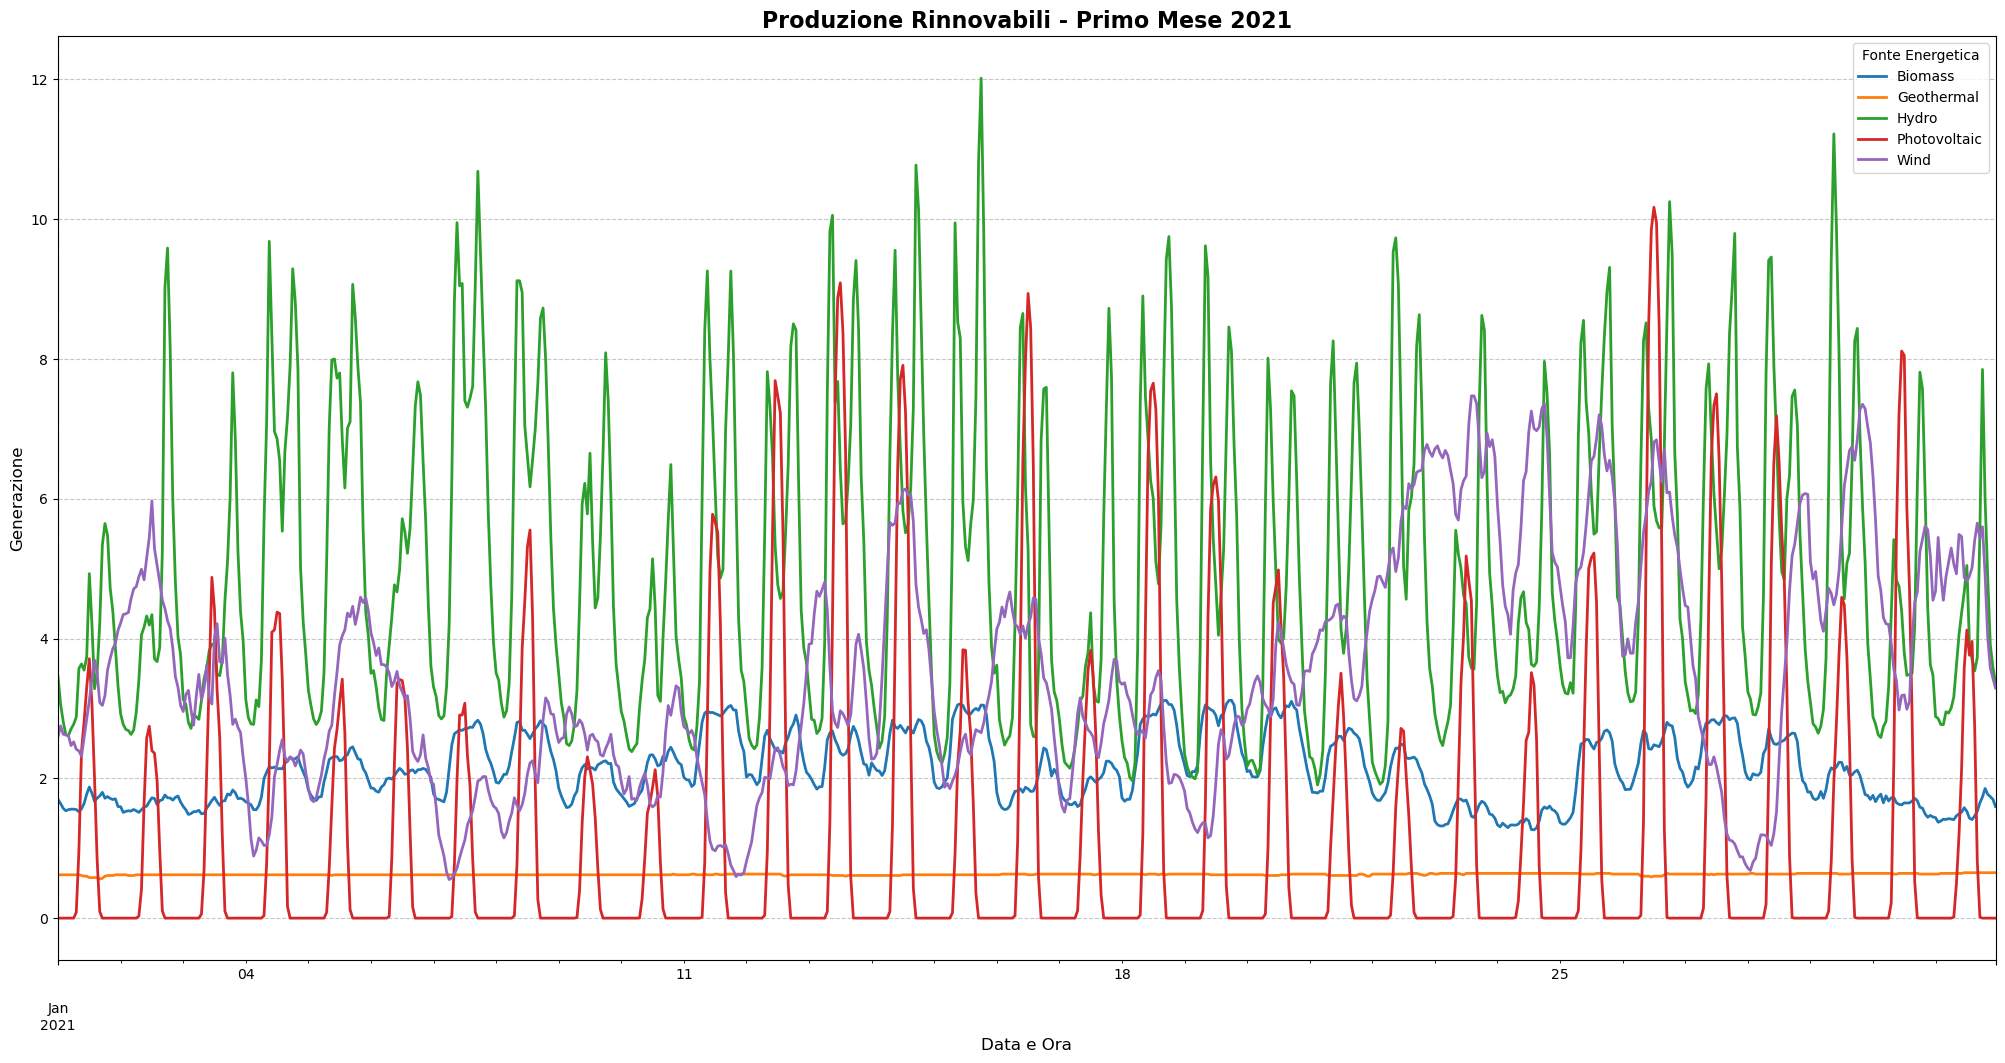

In [45]:
import matplotlib.pyplot as plt
# 1. Pandas crea il grafico base (selezioniamo solo i primi 7 giorni del 2021 per non sovraffollare l'immagine)
df_orario.loc['2021-01-01':'2021-01-31'].plot(figsize=(25, 12), linewidth=2)

# 2. Matplotlib (plt) lo abbellisce
plt.title("Produzione Rinnovabili - Primo Mese 2021", fontsize=16, fontweight='bold')
plt.ylabel("Generazione", fontsize=12)
plt.xlabel("Data e Ora", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7) # Aggiunge una griglia leggera per leggere meglio i valori
plt.legend(title="Fonte Energetica")
plt.savefig("Grafico_Primo_Mese_2021.png", dpi=200, bbox_inches='tight')

# 3. Mostra il grafico pulito (senza scritte tecniche sopra)
plt.show()

In [46]:
# Salva il dataset pulito in un nuovo file CSV sul tuo computer
df.to_csv("Rinnovabili_Pulito_2021_2026.csv")

df_orario.to_csv("Rinnovabili_Pulilto_Orario_2021_2026.csv")

In [47]:
df_mesi.to_csv("Rinnovabili_Pulito:Mesi_2021_2026.csv")

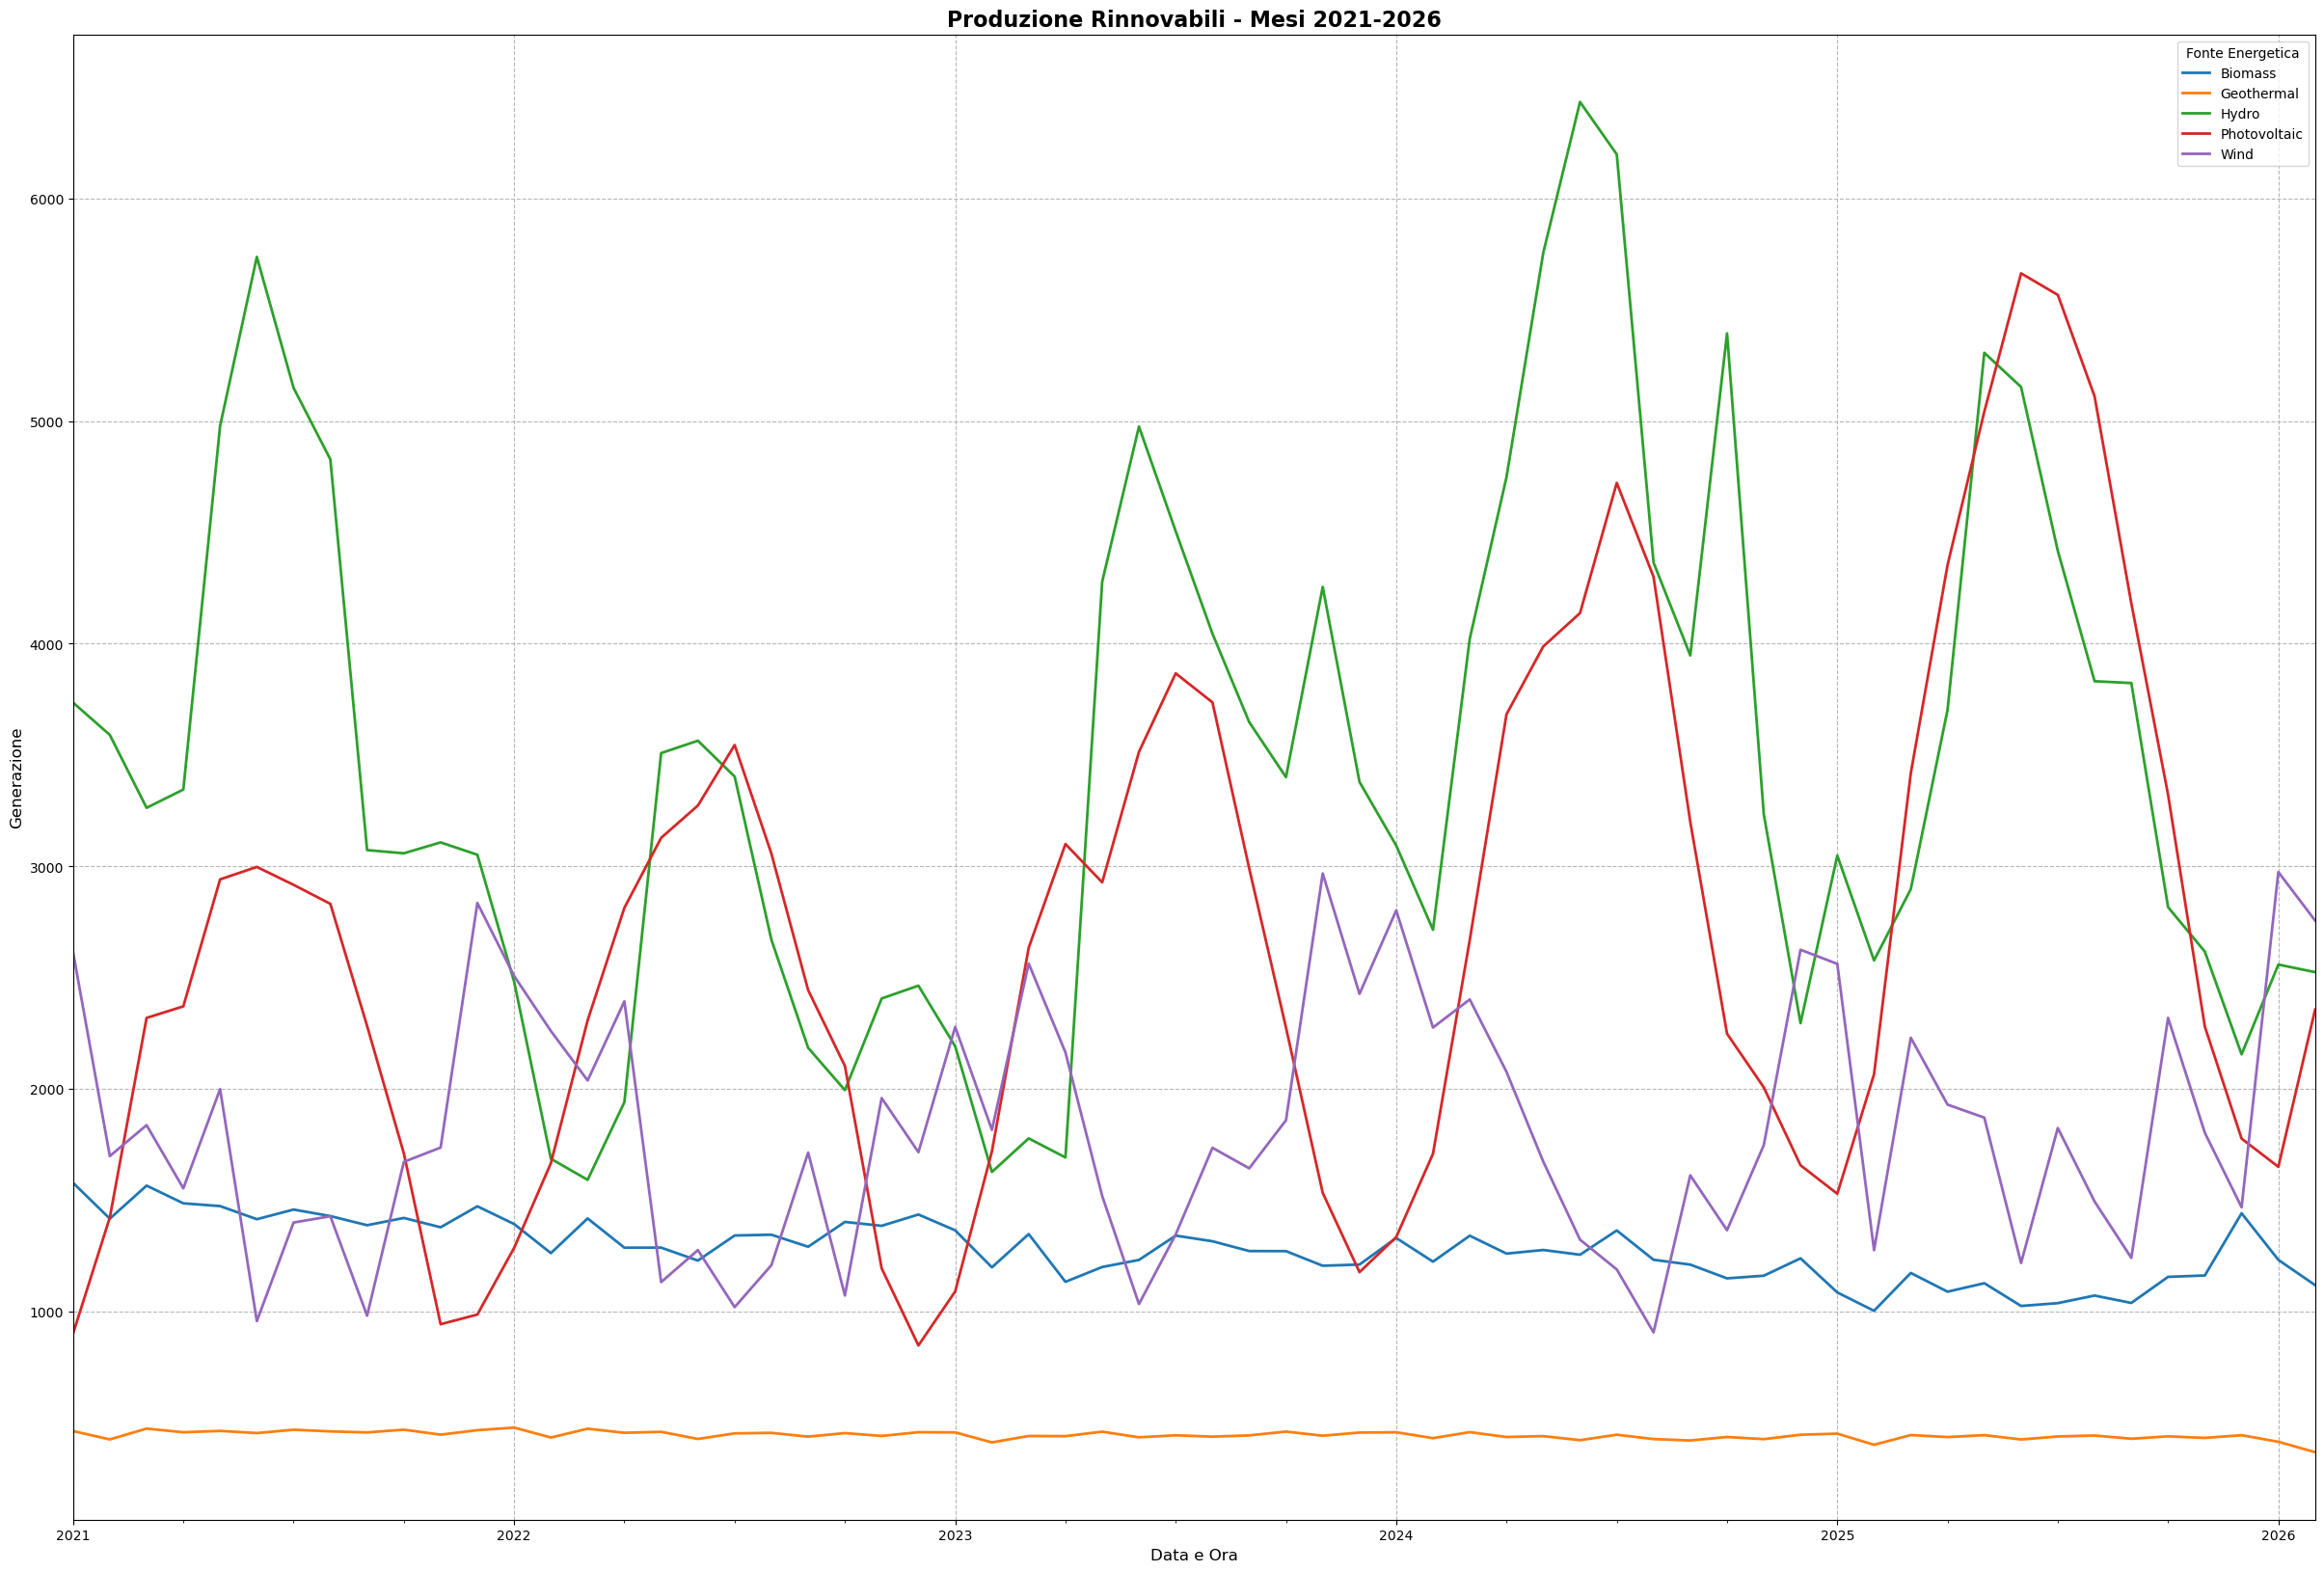

In [48]:
# 1. Pandas crea il grafico base (selezioniamo solo i primi 7 giorni del 2021 per non sovraffollare l'immagine)
df_mesi.loc['2021-01':'2026-02'].plot(figsize=(30, 20), linewidth=2)

# 2. Matplotlib (plt) lo abbellisce
plt.title("Produzione Rinnovabili - Mesi 2021-2026", fontsize=16, fontweight='bold')
plt.ylabel("Generazione", fontsize=12)
plt.xlabel("Data e Ora", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.9) # Aggiunge una griglia leggera per leggere meglio i valori
plt.legend(title="Fonte Energetica")
plt.savefig("Grafico_Mensile_Rinnovabili.png", dpi=300, bbox_inches='tight')

# 3. Mostra il grafico pulito (senza scritte tecniche sopra)
plt.show()

In [51]:
# Confrontiamo i totali annuali per la fonte Hydro
confronto_idrico = df_mesi['Hydro'].resample('Y').sum()
print(confronto_idrico)

Date
2021    46918.706
2022    29903.845
2023    39780.153
2024    52202.110
2025    42350.050
2026     5084.575
Freq: Y-DEC, Name: Hydro, dtype: float64


In [50]:
# Confrontiamo i totali annuali per la fonte Photovoltaic
confronto_solare = df_mesi['Photovoltaic'].resample('Y').sum()
print(confronto_solare)

Date
2021    24632.330
2022    27673.628
2023    30573.615
2024    35660.454
2025    44314.013
2026     4007.921
Freq: Y-DEC, Name: Photovoltaic, dtype: float64


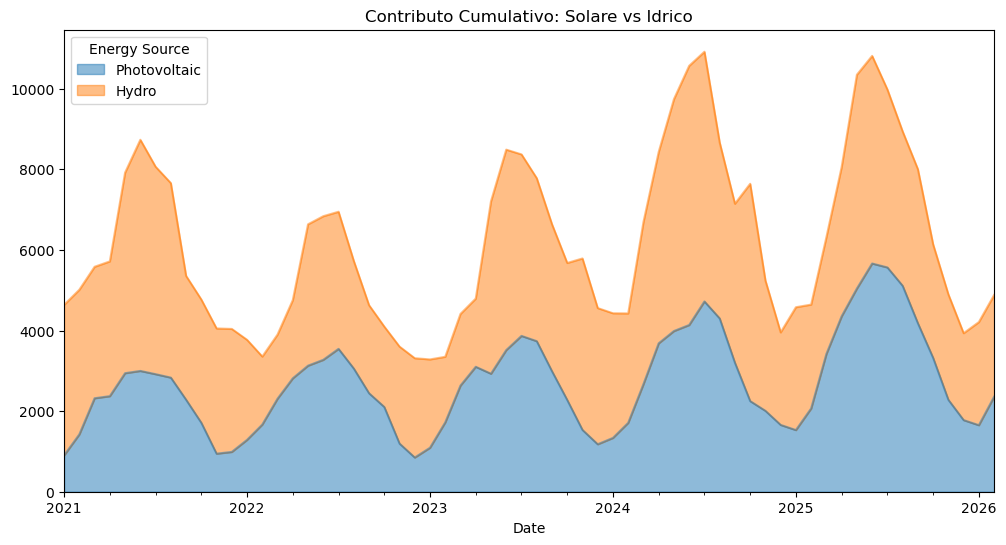

In [52]:
df_mesi[['Photovoltaic', 'Hydro']].plot(kind='area', figsize=(12, 6), alpha=0.5)
plt.title("Contributo Cumulativo: Solare vs Idrico")
plt.show()

In [53]:
colonne_fonti = ['Biomass','Geothermal','Hydro','Photovoltaic','Wind']

df_mesi['Totale_rinnovabili'] = df_mesi[colonne_fonti].sum(axis=1)  #axis=1 è la somma degli elementi sulla riga
df_mesi


Energy Source,Biomass,Geothermal,Hydro,Photovoltaic,Wind,Totale_rinnovabili
Date,,,,,,
2021-01,1579.200,464.485,3735.671,902.158,2615.172,9296.686
2021-02,1418.232,426.850,3590.643,1423.348,1699.267,8558.340
2021-03,1566.634,475.560,3263.113,2319.726,1838.063,9463.096
2021-04,1487.184,459.040,3345.190,2371.714,1554.452,9217.580
2021-05,1474.692,465.170,4977.786,2941.709,1999.789,11859.146
...,...,...,...,...,...,...
2025-10,1156.928,440.780,2816.993,3321.774,2319.776,10056.251
2025-11,1163.135,433.660,2617.487,2280.879,1803.716,8298.877
2025-12,1442.446,445.860,2156.282,1777.739,1469.436,7291.763


In [54]:
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

df_2024 = pd.read_excel("File anno per anno/Generazione_2024.xlsx")
df_2025 = pd.read_excel("File anno per anno/Generazione_2025.xlsx")

print("=== 2024 ===")
print("Shape:", df_2024.shape)
print("Colonne:", df_2024.columns.tolist())
print(df_2024.head(3))

print("\n=== 2025 ===")
print("Shape:", df_2025.shape)
print("Colonne:", df_2025.columns.tolist())
print(df_2025.head(3))

=== 2024 ===
Shape: (43921, 3)
Colonne: ['Date', 'Renewable Generation', 'Energy Source']
                  Date  Renewable Generation Energy Source
0  2024-12-31 23:00:00                 0.000  Photovoltaic
1  2024-12-31 23:00:00                 0.600    Geothermal
2  2024-12-31 23:00:00                 1.502       Biomass

=== 2025 ===
Shape: (175171, 3)
Colonne: ['Date', 'Renewable Generation', 'Energy Source']
                  Date  Renewable Generation Energy Source
0  2025-12-31 23:45:00                 1.640       Biomass
1  2025-12-31 23:45:00                 1.104          Wind
2  2025-12-31 23:45:00                 0.600    Geothermal
